# Classification Algorithms on the Adult Dataset

Dataset: **Adult Dataset (Census Income)** - Predict if income exceeds $50K/yr based on census data. Available on https://archive.ics.uci.edu/dataset/2/adult.

In [2]:
from sklearn.datasets import fetch_openml

adult = fetch_openml(name='adult',  version=2)

In [3]:
print(adult.DESCR)

**Author**: Ronny Kohavi and Barry Becker  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/Adult) - 1996  
**Please cite**: Ron Kohavi, "Scaling Up the Accuracy of Naive-Bayes Classifiers: a Decision-Tree Hybrid", Proceedings of the Second International Conference on Knowledge Discovery and Data Mining, 1996  

Prediction task is to determine whether a person makes over 50K a year. Extraction was done by Barry Becker from the 1994 Census database. A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))

This is the original version from the UCI repository, with training and test sets merged.

### Variable description

Variables are all self-explanatory except __fnlwgt__. This is a proxy for the demographic background of the people: "People with similar demographic characteristics should have similar weights". This similarity-statement is not transferable across the 51 different states.

Description f

In [4]:
adult.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [5]:
X, y = adult.data, adult.target

---

## Data Structure & Data Cleaning

In [6]:
y.value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [7]:
y = y.map({'<=50K': 0, '>50K': 1})

In [8]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [9]:
X['fnlwgt'].value_counts()

fnlwgt
203488    21
120277    19
190290    19
125892    18
126569    18
          ..
345898     1
252208     1
129912     1
255835     1
257302     1
Name: count, Length: 28523, dtype: int64

In [10]:
X.drop(columns='fnlwgt', inplace=True)

In [11]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   education       48842 non-null  category
 3   education-num   48842 non-null  int64   
 4   marital-status  48842 non-null  category
 5   occupation      46033 non-null  category
 6   relationship    48842 non-null  category
 7   race            48842 non-null  category
 8   sex             48842 non-null  category
 9   capital-gain    48842 non-null  int64   
 10  capital-loss    48842 non-null  int64   
 11  hours-per-week  48842 non-null  int64   
 12  native-country  47985 non-null  category
dtypes: category(8), int64(5)
memory usage: 2.2 MB


'?' replaced with NaN to handle missing values

In [12]:
import numpy as np

X = X.replace('?', np.nan)

In [13]:
X.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [14]:
adult_nan_count = X.isnull().sum()
print(adult_nan_count)

age                  0
workclass         2799
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64


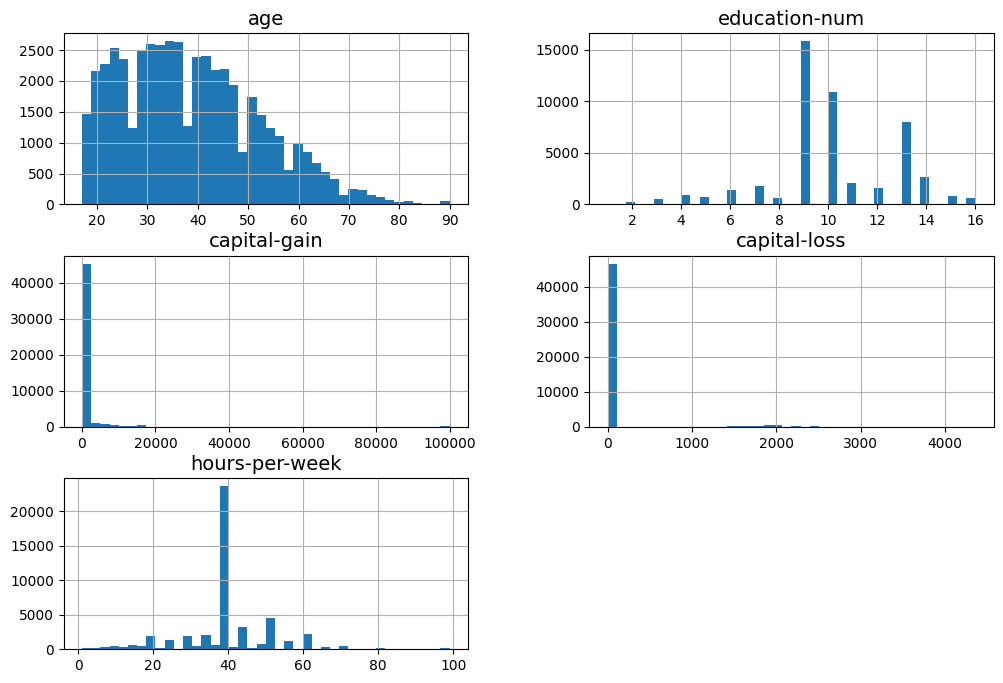

In [15]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

X.hist(bins=40, figsize=(12, 8))
plt.show()

PowerTransformer applied to capital-gain and capital-loss to reduce skewness

In [16]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
X['capital-gain'] = pt.fit_transform(X[['capital-gain']])
X['capital-loss'] = pt.fit_transform(X[['capital-loss']])

Data splitted into training and testing sets (80/20 split) with stratification to maintain class distribution

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y ,random_state=2206)

---

## Pipelines and Models

In [18]:
numeric_features = X.select_dtypes(include=[np.number]).columns

categorical_features = X.select_dtypes(exclude=[np.number]).columns

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [20]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

### SGD Classifier

In [21]:
from sklearn.linear_model import SGDClassifier

sgd_clf_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('sgd_clf', SGDClassifier(random_state=622))
])

In [22]:
sgd_clf_param_grid = {
    'sgd_clf__loss': ['log_loss', 'squared_error', 'hinge'],
    'sgd_clf__penalty': ['l2', 'l1'],
    'sgd_clf__alpha': [0.0001, 0.001, 0.01]
}

In [23]:
from sklearn.model_selection import RandomizedSearchCV

sgd_clf_search = RandomizedSearchCV(estimator = sgd_clf_pipeline,
                            param_distributions= sgd_clf_param_grid,
                            n_iter = 10,
                            cv= 3,
                            random_state=622,
                            verbose = 2,
                            n_jobs=-1)

sgd_clf_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=622))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'sgd_clf__alpha': [0.0001, 0.001, ...], 'sgd_clf__loss': ['log_loss', 'squared_error', ...], 'sgd_clf__penalty': ['l2', 'l1']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versio

In [24]:
sgd_clf_search.best_params_

{'sgd_clf__penalty': 'l1',
 'sgd_clf__loss': 'log_loss',
 'sgd_clf__alpha': 0.0001}

In [25]:
sgd_clf_best_score = sgd_clf_search.best_score_

sgd_clf_best_score

np.float64(0.8430374064083277)

In [26]:
sgd_clf_final_model = sgd_clf_search.best_estimator_

### Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('random_forest', RandomForestClassifier())
])

In [28]:
from scipy.stats import randint

rf_param_grid = [{
    'random_forest__max_features': ['sqrt', 'log2'],
    'random_forest__min_samples_split': randint(low=2, high=15),
    'random_forest__n_estimators': [100, 150, 200]
    }]

In [29]:
rf_search = RandomizedSearchCV(estimator = rf_pipeline,
                            param_distributions= rf_param_grid,
                            n_iter = 10,
                            cv= 3,
                            random_state=622,
                            verbose = 2,
                            n_jobs=-1)

rf_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'random_forest__max_features': ['sqrt', 'log2'], 'random_forest__min_samples_split': <scipy.stats....0057BA98C1F90>, 'random_forest__n_estimators': [100, 150, ...]}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation st

In [30]:
rf_search.best_params_

{'random_forest__max_features': 'sqrt',
 'random_forest__min_samples_split': 14,
 'random_forest__n_estimators': 200}

In [31]:
rf_best_score = rf_search.best_score_
rf_best_score

np.float64(0.8582653256117747)

In [32]:
rf_final_model = rf_search.best_estimator_

In [33]:
feature_importances = rf_final_model['random_forest'].feature_importances_
feature_importances.round(2)


array([0.13, 0.09, 0.14, 0.02, 0.08, 0.01, 0.  , 0.  , 0.01, 0.01, 0.01,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.01, 0.  , 0.01, 0.01, 0.  , 0.01, 0.01, 0.01, 0.  , 0.09,
       0.  , 0.04, 0.  , 0.  , 0.  , 0.  , 0.01, 0.03, 0.01, 0.  , 0.  ,
       0.01, 0.  , 0.02, 0.  , 0.01, 0.  , 0.  , 0.  , 0.07, 0.02, 0.  ,
       0.01, 0.01, 0.01, 0.  , 0.  , 0.  , 0.  , 0.01, 0.01, 0.01, 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  ])

In [34]:
feature_names = rf_final_model['preprocessor'].get_feature_names_out()

In [35]:
sorted(zip(feature_importances, feature_names), reverse=True)

[(np.float64(0.14385243838523964), 'num__capital-gain'),
 (np.float64(0.1317691434408535), 'num__age'),
 (np.float64(0.09275004382082484), 'num__education-num'),
 (np.float64(0.09247431815394318), 'cat__marital-status_Married-civ-spouse'),
 (np.float64(0.07991575224434475), 'num__hours-per-week'),
 (np.float64(0.06761453807010008), 'cat__relationship_Husband'),
 (np.float64(0.03981990064411164), 'cat__marital-status_Never-married'),
 (np.float64(0.02650392842249573), 'cat__occupation_Exec-managerial'),
 (np.float64(0.021629185848680694), 'cat__occupation_Prof-specialty'),
 (np.float64(0.017168179865266024), 'num__capital-loss'),
 (np.float64(0.015265153364027041), 'cat__relationship_Not-in-family'),
 (np.float64(0.01485413913341744), 'cat__education_Bachelors'),
 (np.float64(0.01401111626244432), 'cat__relationship_Wife'),
 (np.float64(0.013958637323619856), 'cat__relationship_Own-child'),
 (np.float64(0.0124962411375497), 'cat__sex_Female'),
 (np.float64(0.010061511977172474), 'cat__s

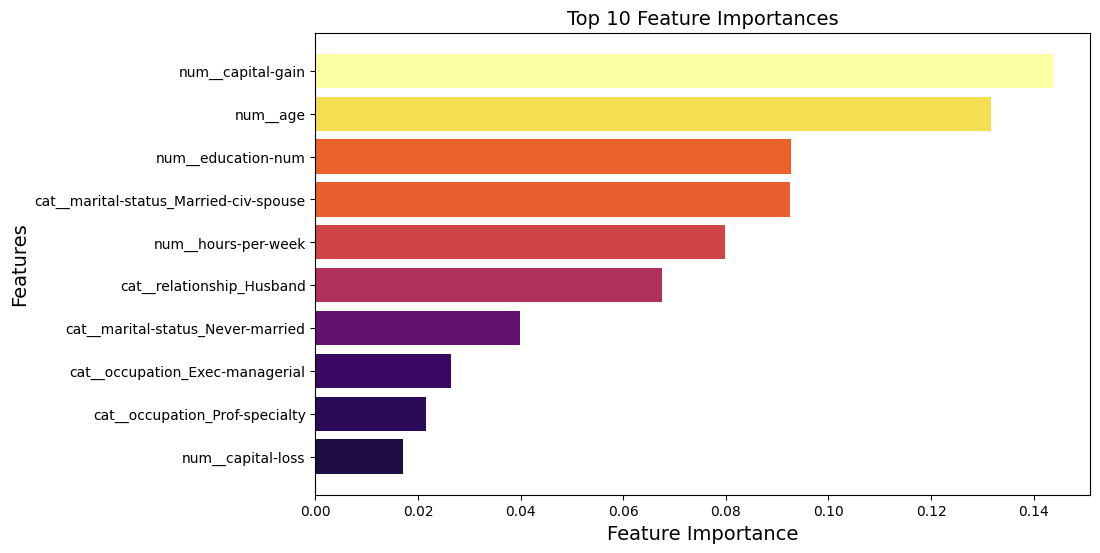

In [36]:
import matplotlib.pyplot as plt

indices = np.argsort(feature_importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[indices], feature_importances[indices], color=plt.cm.inferno(feature_importances[indices] / max(feature_importances)))
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances')
plt.show()


### K-Nearest Neighbors

In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])

In [38]:
knn_param_grid = [{'knn__weights': ['uniform', 'distance'],
                'knn__n_neighbors': randint(low=2, high=12)
                }]

In [39]:
knn_search = RandomizedSearchCV(estimator = knn_pipeline,
                            param_distributions= knn_param_grid,
                            n_iter = 10,
                            cv= 3,
                            random_state=622,
                            verbose = 2,
                            n_jobs=-1)
    

knn_search.fit(X_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'knn__n_neighbors': <scipy.stats....0057BA98DCE50>, 'knn__weights': ['uniform', 'distance']}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default v

In [40]:
knn_search.best_params_

{'knn__n_neighbors': 11, 'knn__weights': 'uniform'}

In [41]:
knn_best_score = knn_search.best_score_
knn_best_score

np.float64(0.8376373025005462)

In [42]:
knn_final_model = knn_search.best_estimator_

### Histogram-based Gradient Boosting Classification Tree

In [43]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('hgb_clf', HistGradientBoostingClassifier())
])

In [44]:
from scipy.stats import uniform

hgb_clf_param_grid = [{'hgb_clf__learning_rate': uniform(0, 1),
                       'hgb_clf__max_bins': randint(low=100, high=255),
                       'hgb_clf__max_leaf_nodes': randint(low=5, high=10),
                       'hgb_clf__l2_regularization': uniform(0, 1)}]

In [45]:
hgb_clf_search = RandomizedSearchCV(estimator = hgb_clf_pipeline,
                            param_distributions= hgb_clf_param_grid,
                            n_iter = 10,
                            cv= 3,
                            random_state=622,
                            verbose = 2,
                            n_jobs=-1)
    

hgb_clf_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'hgb_clf__l2_regularization': <scipy.stats....0057BA98D7F90>, 'hgb_clf__learning_rate': <scipy.stats....0057BA98C8590>, 'hgb_clf__max_bins': <scipy.stats....0057BA98DD710>, 'hgb_clf__max_leaf_nodes': <scipy.stats....0057BA98D8490>}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same acros

In [46]:
hgb_clf_search.best_params_

{'hgb_clf__l2_regularization': np.float64(0.7747901709800534),
 'hgb_clf__learning_rate': np.float64(0.46280875519374964),
 'hgb_clf__max_bins': 137,
 'hgb_clf__max_leaf_nodes': 9}

In [47]:
hgb_clf_best_score = hgb_clf_search.best_score_
hgb_clf_best_score

np.float64(0.8717528700398183)

In [48]:
hgb_clf_final_model = hgb_clf_search.best_estimator_

---

## Model Evaluation: ROC and Precision-Recall Curves

In [49]:
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.model_selection import cross_val_predict

sgd_clf_scores = cross_val_predict(sgd_clf_final_model, X_train, y_train, cv=3, method='decision_function')

sgd_clf_fpr, sgd_clf_tpr, sgd_clf_thresholds = roc_curve(y_train, sgd_clf_scores)

precisions_sgd_clf, recalls_sgd_clf, thresholds_sgd_clf = precision_recall_curve(y_train, sgd_clf_scores)

In [50]:
rf_probas = cross_val_predict(rf_final_model, X_train, y_train, cv=3, method='predict_proba')

rf_scores = rf_probas[:, 1]

rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_train, rf_scores)

precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(y_train, rf_scores)

In [51]:
knn_probas = cross_val_predict(knn_final_model, X_train, y_train, cv=3, method='predict_proba')

knn_scores = knn_probas[:, 1]

knn_fpr, knn_tpr, knn_thresholds = roc_curve(y_train, knn_scores)

precisions_knn, recalls_knn, thresholds_knn = precision_recall_curve(y_train, knn_scores)

In [52]:
hgb_scores = cross_val_predict(hgb_clf_final_model, X_train, y_train, cv=3, method='decision_function')

hgb_fpr, hgb_tpr, hgb_thresholds = roc_curve(y_train, hgb_scores)

precisions_hgb, recalls_hgb, thresholds_hgb = precision_recall_curve(y_train, hgb_scores)

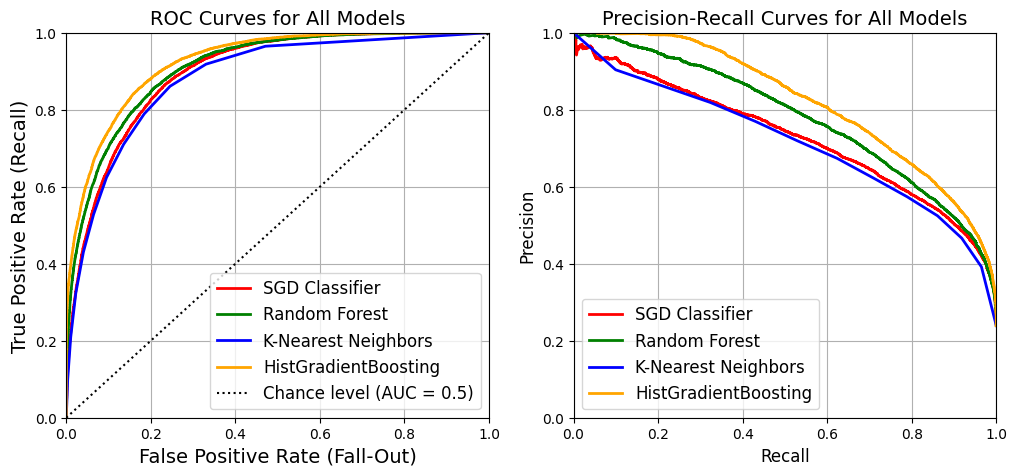

In [53]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 5))
ax1.grid(True)
ax1.set_title("ROC Curves for All Models", fontsize=14)
ax1.plot(sgd_clf_fpr, sgd_clf_tpr, linewidth=2, label="SGD Classifier", color="red")
ax1.plot(rf_fpr, rf_tpr, linewidth=2, label="Random Forest", color="green")
ax1.plot(knn_fpr, knn_tpr, linewidth=2, label="K-Nearest Neighbors", color="blue")
ax1.plot(hgb_fpr, hgb_tpr, linewidth=2, label="HistGradientBoosting", color="orange")
ax1.plot([0, 1], [0, 1], 'k:', label="Chance level (AUC = 0.5)")
ax1.set_xlabel('False Positive Rate (Fall-Out)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.axis([0, 1, 0, 1])
ax1.legend(loc="lower right", fontsize=12)

ax2.grid(True)
ax2.set_title("Precision-Recall Curves for All Models", fontsize=14)
ax2.plot(recalls_sgd_clf, precisions_sgd_clf, linewidth=2, label="SGD Classifier", color="red")
ax2.plot(recalls_rf, precisions_rf, linewidth=2, label="Random Forest", color="green")
ax2.plot(recalls_knn, precisions_knn, linewidth=2, label="K-Nearest Neighbors", color="blue")
ax2.plot(recalls_hgb, precisions_hgb, linewidth=2, label="HistGradientBoosting", color="orange")
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.axis([0, 1, 0, 1])
ax2.legend(loc="lower left", fontsize=12)

plt.show()

In [54]:
from  sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

sgd_clf_pred = cross_val_predict(sgd_clf_final_model, X_train, y_train, cv=3)

sgd_clf_precision = precision_score(y_train, sgd_clf_pred)
    
sgd_clf_recall = recall_score(y_train, sgd_clf_pred)

sgd_clf_f1 = f1_score(y_train, sgd_clf_pred)

sgd_clf_roc_auc_score = roc_auc_score(y_train, sgd_clf_scores)

In [55]:
rf_roc_auc_score = roc_auc_score(y_train, rf_scores)

rf_pred = cross_val_predict(rf_final_model, X_train, y_train, cv=3)

rf_precision = precision_score(y_train, rf_pred)

rf_recall = recall_score(y_train, rf_pred)

rf_f1 = f1_score(y_train, rf_pred)

In [56]:
knn_roc_auc_score = roc_auc_score(y_train, knn_scores)

knn_pred = cross_val_predict(knn_final_model, X_train, y_train, cv=3)

knn_precision = precision_score(y_train, knn_pred)

knn_recall = recall_score(y_train, knn_pred)

knn_f1 = f1_score(y_train, knn_pred)


In [57]:
hgb_roc_auc_score = roc_auc_score(y_train, hgb_scores)

hgb_pred = cross_val_predict(hgb_clf_final_model, X_train, y_train, cv=3)

hgb_precision = precision_score(y_train, hgb_pred)

hgb_recall = recall_score(y_train, hgb_pred)

hgb_f1 = f1_score(y_train, hgb_pred)

In [58]:
import pandas as pd

model_results = pd.DataFrame({
    'Model': ['SGD Classifier', 'Random Forest', 'K-Nearest Neighbors', 'HistGradientBoosting'],
    'Best CV Score': [sgd_clf_best_score, rf_best_score, knn_best_score, hgb_clf_best_score],
    'ROC AUC Score': [sgd_clf_roc_auc_score, rf_roc_auc_score, knn_roc_auc_score, hgb_roc_auc_score],
    'Precision': [sgd_clf_precision, rf_precision, knn_precision, hgb_precision],
    'Recall': [sgd_clf_recall, rf_recall, knn_recall, hgb_recall],
    'F1 Score': [sgd_clf_f1, rf_f1, knn_f1, hgb_f1]
})

model_results.round(2)

,Model,Best CV Score,ROC AUC Score,Precision,Recall,F1 Score
0,SGD Classifier,0.84,0.90,0.71,0.57,0.64
1,Random Forest,0.86,0.91,0.74,0.62,0.67
2,K-Nearest Neighbors,0.84,0.88,0.67,0.62,0.65
3,HistGradientBoosting,0.87,0.93,0.77,0.65,0.71


## Best Model Evaluation on the Test Set

In [59]:
hgb_clf_final_model.score(X_test, y_test)

0.8755246186917801